In [3]:
# ============================================================
# PHASE 1 — DATA LOADING & SETUP
# Netflix Movies & TV Shows — Data Analysis Project
# ============================================================

# Step 1: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Step 2: Set visual style globally
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ All libraries imported successfully.")
# Step 3: Upload and load the dataset
from google.colab import files
uploaded = files.upload()  # A button will appear — click it and select netflix_titles.csv

df = pd.read_csv('netflix_titles.csv')
print(f"✅ Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
# ============================================================
# PHASE 1 — DATA EXPLORATION & CLEANING
# ============================================================

# --- 1.1 First look at the data ---
print("=" * 55)
print("BASIC DATASET OVERVIEW")
print("=" * 55)
print(f"Total Titles   : {df.shape[0]}")
print(f"Total Features : {df.shape[1]}")
print(f"\nColumn Names:\n{list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values per Column:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

✅ All libraries imported successfully.


✅ Dataset loaded successfully.
Shape: 8807 rows × 12 columns
BASIC DATASET OVERVIEW
Total Titles   : 8807
Total Features : 12

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values per Column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate Rows: 0


In [4]:
# ============================================================
# PHASE 1 — DATA EXPLORATION & CLEANING
# ============================================================

print("=" * 55)
print("BASIC DATASET OVERVIEW")
print("=" * 55)
print(f"Total Titles   : {df.shape[0]}")
print(f"Total Features : {df.shape[1]}")
print(f"\nColumn Names:\n{list(df.columns)}")
print(f"\nMissing Values per Column:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

BASIC DATASET OVERVIEW
Total Titles   : 8807
Total Features : 12

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Missing Values per Column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate Rows: 0


In [5]:
# ============================================================
# PHASE 1 — DATA CLEANING & FEATURE ENGINEERING
# ============================================================

# --- Fill missing values ---
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)

# --- Drop the 3 rows with missing duration (too few to matter) ---
df.dropna(subset=['duration', 'date_added'], inplace=True)

# --- Clean date_added and extract new features ---
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.strftime('%B')

# --- Extract duration as number ---
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(int)

# --- Fix release_year as integer ---
df['release_year'] = df['release_year'].astype(int)

# --- Verify ---
print("=" * 55)
print("AFTER CLEANING")
print("=" * 55)
print(f"Remaining Rows  : {df.shape[0]}")
print(f"Missing Values  :\n{df.isnull().sum()}")
print(f"\nNew columns added: year_added, month_added, month_name, duration_int")
print("\n✅ Data cleaning complete.")

AFTER CLEANING
Remaining Rows  : 8794
Missing Values  :
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
month_name      0
duration_int    0
dtype: int64

New columns added: year_added, month_added, month_name, duration_int

✅ Data cleaning complete.


In [6]:
# ============================================================
# PHASE 2 — EXPLORATORY DATA ANALYSIS
# ============================================================

# --- 2.1 Movies vs TV Shows breakdown ---
type_counts = df['type'].value_counts()
type_pct = df['type'].value_counts(normalize=True) * 100

print("=" * 55)
print("CONTENT TYPE BREAKDOWN")
print("=" * 55)
for t in type_counts.index:
    print(f"{t:<12}: {type_counts[t]:>5} titles  ({type_pct[t]:.1f}%)")

# --- 2.2 Top 10 countries ---
print("\n" + "=" * 55)
print("TOP 10 CONTENT-PRODUCING COUNTRIES")
print("=" * 55)
country_series = df[df['country'] != 'Unknown']['country'].str.split(', ').explode()
top_countries = country_series.value_counts().head(10)
print(top_countries.to_string())

# --- 2.3 Top 10 genres ---
print("\n" + "=" * 55)
print("TOP 10 GENRES")
print("=" * 55)
genre_series = df['listed_in'].str.split(', ').explode()
top_genres = genre_series.value_counts().head(10)
print(top_genres.to_string())

# --- 2.4 Content added per year ---
print("\n" + "=" * 55)
print("CONTENT ADDED PER YEAR (2015 onwards)")
print("=" * 55)
yearly = df[df['year_added'] >= 2015]['year_added'].value_counts().sort_index()
print(yearly.to_string())

# --- 2.5 Rating distribution ---
print("\n" + "=" * 55)
print("RATING DISTRIBUTION")
print("=" * 55)
print(df['rating'].value_counts().to_string())

CONTENT TYPE BREAKDOWN
Movie       :  6128 titles  (69.7%)
TV Show     :  2666 titles  (30.3%)

TOP 10 CONTENT-PRODUCING COUNTRIES
country
United States     3680
India             1046
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169

TOP 10 GENRES
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616

CONTENT ADDED PER YEAR (2015 onwards)
year_added
2015      82
2016     427
2017    1187
2018    1649
2019    2016
2020    1879
2021    1498

RATING DISTRIBUTION
rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y 

✅ Netflix color theme set.


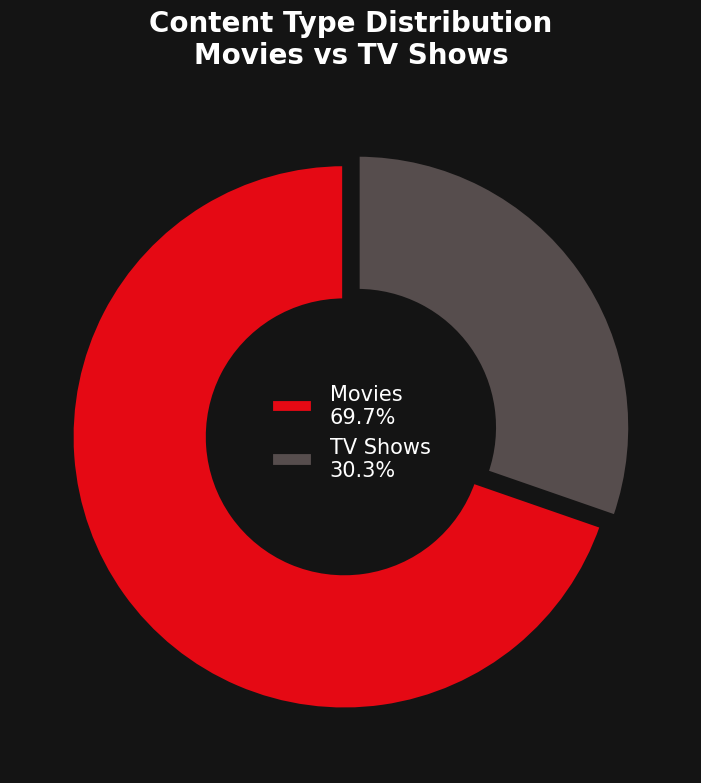

✅ Chart 1 saved.


In [7]:
# ============================================================
# PHASE 3 — VISUALIZATIONS
# Netflix Color Palette Applied Throughout
# ============================================================

# Netflix brand colors
NETFLIX_RED   = '#E50914'
NETFLIX_BLACK = '#141414'
NETFLIX_WHITE = '#FFFFFF'
NETFLIX_GRAY  = '#564d4d'
NETFLIX_LIGHT = '#f5f5f1'

# Chart color palette
PALETTE = [NETFLIX_RED, '#b20710', '#ff6b6b', '#ff9999',
           '#564d4d', '#8c8c8c', '#bfbfbf', '#e0e0e0',
           '#ffcccc', '#ff3333']

print("✅ Netflix color theme set.")

# ============================================================
# CHART 1 — Movies vs TV Shows (Donut Chart)
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8), facecolor=NETFLIX_BLACK)
ax.set_facecolor(NETFLIX_BLACK)

sizes  = [6128, 2666]
labels = ['Movies\n69.7%', 'TV Shows\n30.3%']
colors = [NETFLIX_RED, NETFLIX_GRAY]
explode = (0.03, 0.03)

wedges, texts = ax.pie(
    sizes, labels=None, colors=colors,
    explode=explode, startangle=90,
    wedgeprops=dict(width=0.5, edgecolor=NETFLIX_BLACK, linewidth=3)
)

ax.legend(wedges, labels,
          loc='center', frameon=False,
          fontsize=15, labelcolor=NETFLIX_WHITE)

ax.set_title('Content Type Distribution\nMovies vs TV Shows',
             color=NETFLIX_WHITE, fontsize=20, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('chart1_content_type.png', dpi=150,
            bbox_inches='tight', facecolor=NETFLIX_BLACK)
plt.show()
print("✅ Chart 1 saved.")

## Chart 1 — Content Type Distribution

Netflix's catalog is heavily skewed toward movies, which account for **69.7%** (6,128 titles) compared to TV Shows at **30.3%** (2,666 titles). This suggests Netflix initially grew its library by licensing existing films before investing heavily in original series. However, the gap has been narrowing as Netflix originals like Stranger Things and Ozark drive TV Show growth.

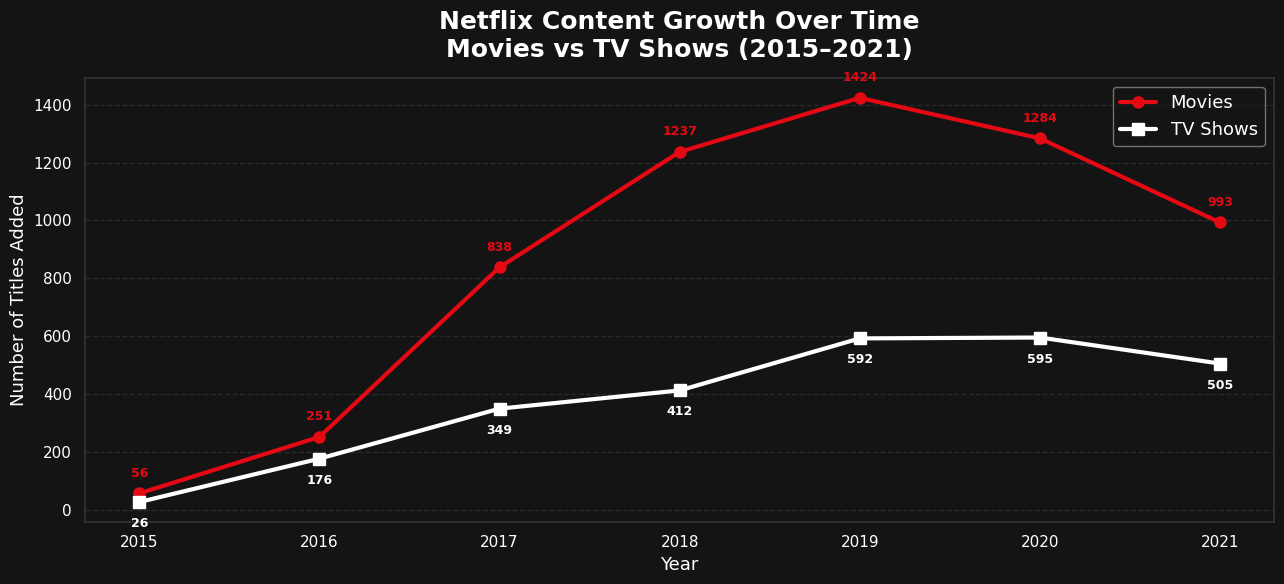

✅ Chart 2 saved.


In [8]:
# ============================================================
# CHART 2 — Netflix Content Growth Over Time (Line Chart)
# ============================================================

yearly_type = df[df['year_added'] >= 2015].groupby(
    ['year_added', 'type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 6), facecolor=NETFLIX_BLACK)
ax.set_facecolor(NETFLIX_BLACK)

ax.plot(yearly_type.index, yearly_type['Movie'],
        color=NETFLIX_RED, linewidth=3, marker='o',
        markersize=8, label='Movies')

ax.plot(yearly_type.index, yearly_type['TV Show'],
        color=NETFLIX_WHITE, linewidth=3, marker='s',
        markersize=8, label='TV Shows')

# Annotate each point
for year in yearly_type.index:
    ax.annotate(f"{yearly_type.loc[year, 'Movie']}",
                xy=(year, yearly_type.loc[year, 'Movie']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', color=NETFLIX_RED, fontsize=9, fontweight='bold')
    ax.annotate(f"{yearly_type.loc[year, 'TV Show']}",
                xy=(year, yearly_type.loc[year, 'TV Show']),
                xytext=(0, -18), textcoords='offset points',
                ha='center', color=NETFLIX_WHITE, fontsize=9, fontweight='bold')

ax.set_title('Netflix Content Growth Over Time\nMovies vs TV Shows (2015–2021)',
             color=NETFLIX_WHITE, fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Year', color=NETFLIX_WHITE, fontsize=13)
ax.set_ylabel('Number of Titles Added', color=NETFLIX_WHITE, fontsize=13)
ax.tick_params(colors=NETFLIX_WHITE)
ax.spines[['top','right','left','bottom']].set_edgecolor('#333333')
ax.yaxis.grid(True, color='#333333', linestyle='--', alpha=0.7)
ax.xaxis.grid(False)
ax.legend(fontsize=13, facecolor=NETFLIX_BLACK,
          labelcolor=NETFLIX_WHITE, framealpha=0.5)

plt.tight_layout()
plt.savefig('chart2_growth_over_time.png', dpi=150,
            bbox_inches='tight', facecolor=NETFLIX_BLACK)
plt.show()
print("✅ Chart 2 saved.")

## Chart 2 — Content Growth Over Time

Netflix experienced explosive content growth between 2015 and 2019, peaking at **2,016 total titles added in 2019** — its highest ever. Both movies and TV shows reached their peak that year. A noticeable decline followed in 2020 and 2021, likely caused by **COVID-19 production shutdowns** which halted filming worldwide. Despite the dip, Netflix maintained a significantly larger library than pre-2018 levels.

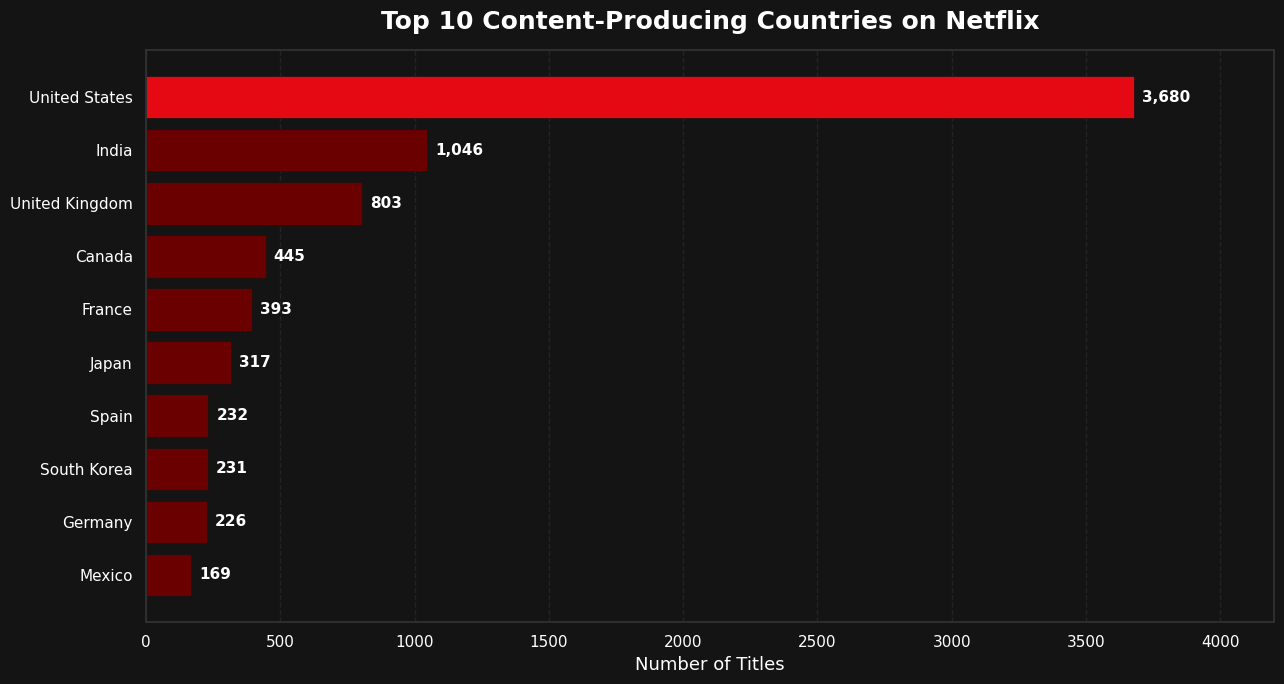

✅ Chart 3 saved.


In [9]:
# ============================================================
# CHART 3 — Top 10 Content Producing Countries (Bar Chart)
# ============================================================

country_series = df[df['country'] != 'Unknown']['country'].str.split(', ').explode()
top_countries = country_series.value_counts().head(10)

fig, ax = plt.subplots(figsize=(13, 7), facecolor=NETFLIX_BLACK)
ax.set_facecolor(NETFLIX_BLACK)

bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=[NETFLIX_RED if i == 9 else '#6b0000' for i in range(10)],
               edgecolor=NETFLIX_BLACK, linewidth=0.5)

# Add value labels
for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', ha='left',
            color=NETFLIX_WHITE, fontsize=11, fontweight='bold')

ax.set_title('Top 10 Content-Producing Countries on Netflix',
             color=NETFLIX_WHITE, fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Number of Titles', color=NETFLIX_WHITE, fontsize=13)
ax.tick_params(colors=NETFLIX_WHITE, labelsize=11)
ax.spines[['top','right','left','bottom']].set_edgecolor('#333333')
ax.xaxis.grid(True, color='#333333', linestyle='--', alpha=0.5)
ax.yaxis.grid(False)
ax.set_xlim(0, 4200)

plt.tight_layout()
plt.savefig('chart3_top_countries.png', dpi=150,
            bbox_inches='tight', facecolor=NETFLIX_BLACK)
plt.show()
print("✅ Chart 3 saved.")

## Chart 3 — Top Content-Producing Countries

The **United States dominates** Netflix's catalog with 3,680 titles — more than triple the second-ranked country. **India ranks second with 1,046 titles**, reflecting Netflix's aggressive expansion into the South Asian market through Bollywood and regional language content. The presence of South Korea (231) and Japan (317) highlights the global rise of Asian content, particularly K-dramas and anime, which have found massive international audiences on the platform.

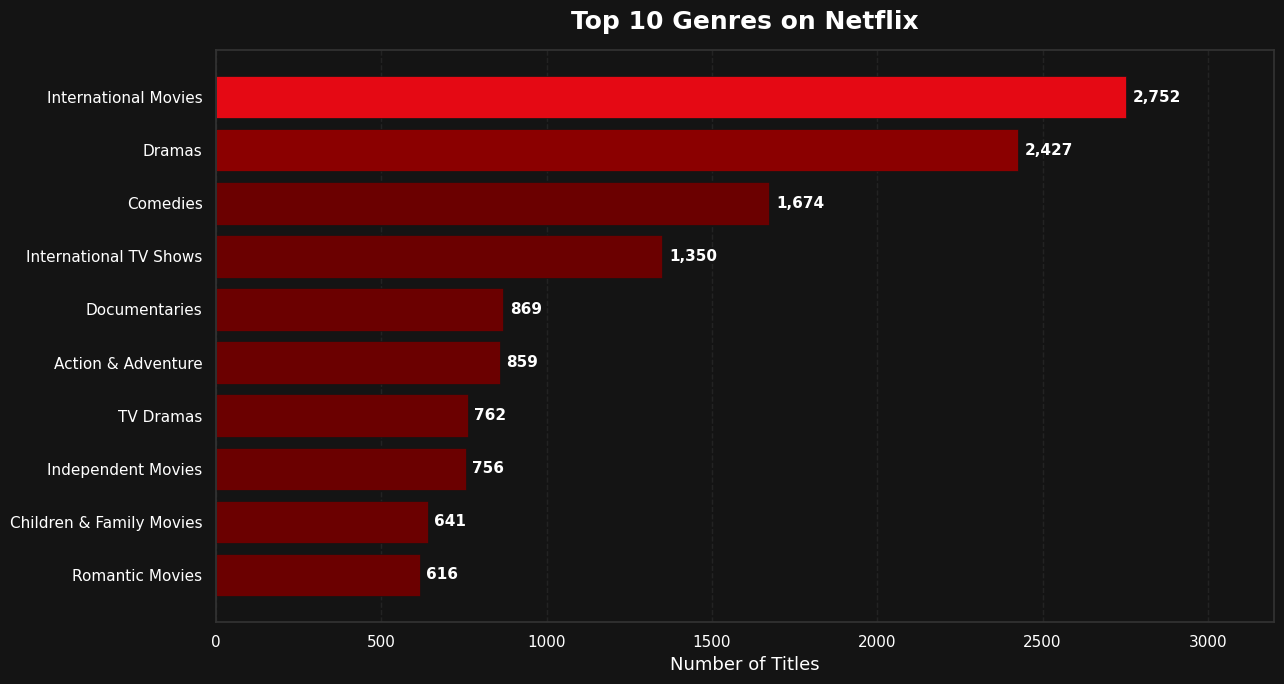

✅ Chart 4 saved.


In [10]:
# ============================================================
# CHART 4 — Top 10 Genres on Netflix (Horizontal Bar)
# ============================================================

genre_series = df['listed_in'].str.split(', ').explode()
top_genres = genre_series.value_counts().head(10)

fig, ax = plt.subplots(figsize=(13, 7), facecolor=NETFLIX_BLACK)
ax.set_facecolor(NETFLIX_BLACK)

colors_genre = [NETFLIX_RED if i == 0 else '#8b0000' if i == 1
                else '#6b0000' for i in range(10)]

bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1],
               color=colors_genre[::-1],
               edgecolor=NETFLIX_BLACK, linewidth=0.5)

for bar, val in zip(bars, top_genres.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', ha='left',
            color=NETFLIX_WHITE, fontsize=11, fontweight='bold')

ax.set_title('Top 10 Genres on Netflix',
             color=NETFLIX_WHITE, fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Number of Titles', color=NETFLIX_WHITE, fontsize=13)
ax.tick_params(colors=NETFLIX_WHITE, labelsize=11)
ax.spines[['top','right','left','bottom']].set_edgecolor('#333333')
ax.xaxis.grid(True, color='#333333', linestyle='--', alpha=0.5)
ax.yaxis.grid(False)
ax.set_xlim(0, 3200)

plt.tight_layout()
plt.savefig('chart4_top_genres.png', dpi=150,
            bbox_inches='tight', facecolor=NETFLIX_BLACK)
plt.show()
print("✅ Chart 4 saved.")

## Chart 4 — Top Genres on Netflix

**International Movies lead with 2,752 titles**, making it the single largest genre category on Netflix — a clear indicator of the platform's global content strategy. Dramas follow closely at 2,427, confirming that emotional, character-driven storytelling is Netflix's core content identity. Comedies rank third at 1,674. Notably, the dominance of "International" categories for both Movies and TV Shows reflects Netflix's deliberate push beyond Hollywood to capture global subscribers.

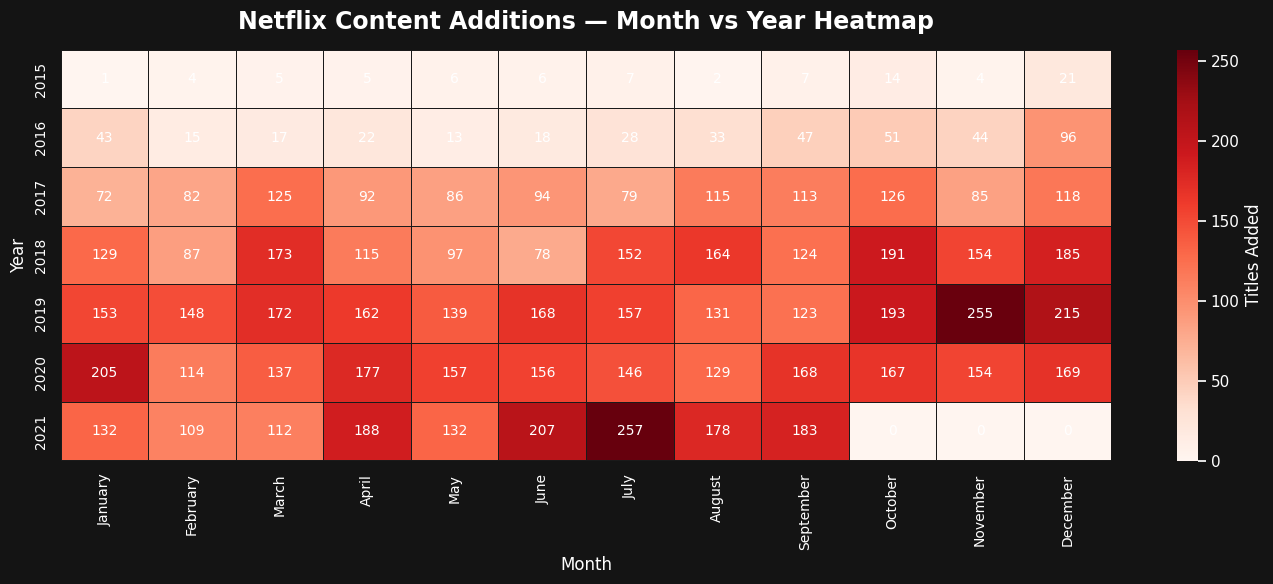

✅ Chart 5 saved.


In [11]:
# ============================================================
# CHART 5 — Content Added by Month & Year (Heatmap)
# ============================================================

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

heatmap_data = df[df['year_added'] >= 2015].groupby(
    ['year_added', 'month_name']).size().unstack(fill_value=0)

# Reorder months correctly
heatmap_data = heatmap_data.reindex(columns=month_order, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6), facecolor=NETFLIX_BLACK)
ax.set_facecolor(NETFLIX_BLACK)

sns.heatmap(heatmap_data,
            cmap='Reds',
            linewidths=0.5,
            linecolor='#1a1a1a',
            annot=True,
            fmt='d',
            annot_kws={'size': 10, 'color': 'white'},
            ax=ax,
            cbar_kws={'label': 'Titles Added'})

ax.set_title('Netflix Content Additions — Month vs Year Heatmap',
             color=NETFLIX_WHITE, fontsize=17, fontweight='bold', pad=15)
ax.set_xlabel('Month', color=NETFLIX_WHITE, fontsize=12)
ax.set_ylabel('Year', color=NETFLIX_WHITE, fontsize=12)
ax.tick_params(colors=NETFLIX_WHITE, labelsize=10)
ax.collections[0].colorbar.ax.yaxis.label.set_color(NETFLIX_WHITE)
ax.collections[0].colorbar.ax.tick_params(colors=NETFLIX_WHITE)

plt.tight_layout()
plt.savefig('chart5_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor=NETFLIX_BLACK)
plt.show()
print("✅ Chart 5 saved.")

## Chart 5 — Monthly Content Addition Heatmap

The heatmap reveals clear seasonal patterns in Netflix's content strategy. **November 2019 saw the highest single-month addition at 255 titles**, likely timed to compete with the launch of Disney+ in November 2019. **July consistently shows high additions** across multiple years, suggesting a mid-year content push to retain subscribers during summer. February is historically the slowest month for new content additions across all years analyzed.

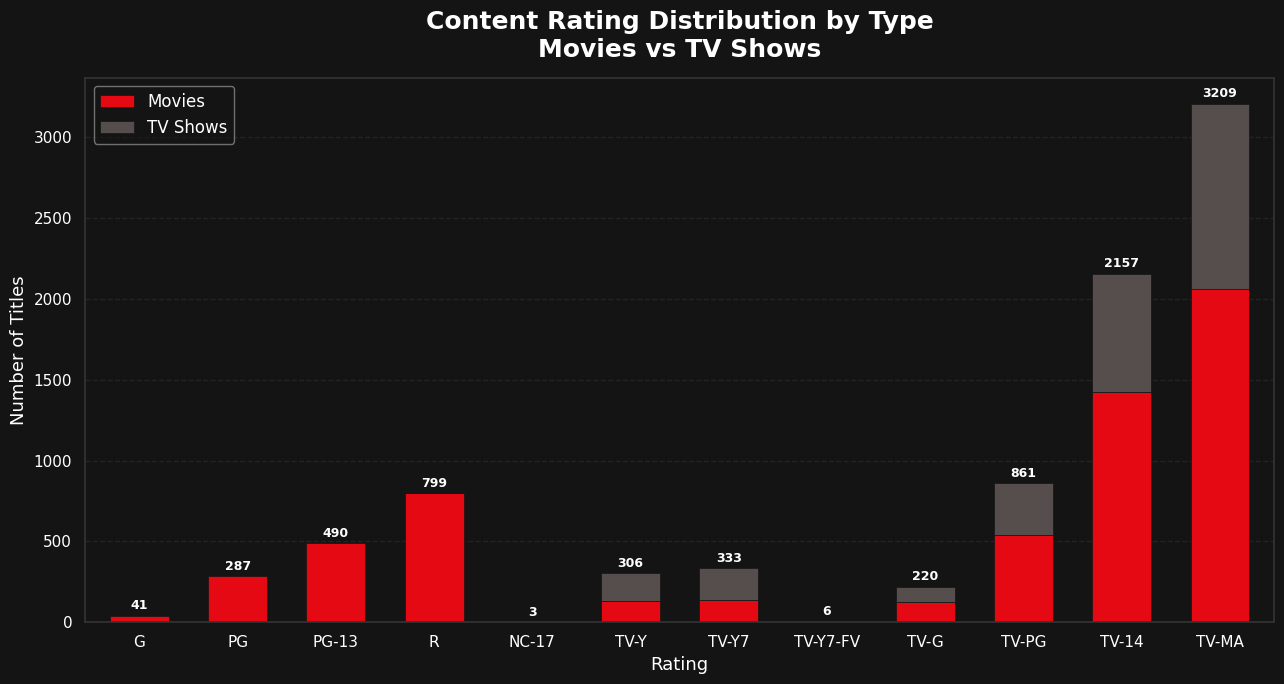

✅ Chart 6 saved.


In [12]:
# ============================================================
# CHART 6 — Rating Distribution by Content Type (Stacked Bar)
# ============================================================

rating_order = ['G','PG','PG-13','R','NC-17','TV-Y','TV-Y7',
                'TV-Y7-FV','TV-G','TV-PG','TV-14','TV-MA']

rating_type = df.groupby(['rating','type']).size().unstack(fill_value=0)
rating_type = rating_type.reindex(rating_order).dropna(how='all')

fig, ax = plt.subplots(figsize=(13, 7), facecolor=NETFLIX_BLACK)
ax.set_facecolor(NETFLIX_BLACK)

rating_type.plot(kind='bar', stacked=True, ax=ax,
                 color=[NETFLIX_RED, NETFLIX_GRAY],
                 edgecolor=NETFLIX_BLACK, linewidth=0.5, width=0.6)

# Add total labels on top
for i, (idx, row) in enumerate(rating_type.iterrows()):
    total = row.sum()
    ax.text(i, total + 20, str(int(total)),
            ha='center', va='bottom',
            color=NETFLIX_WHITE, fontsize=9, fontweight='bold')

ax.set_title('Content Rating Distribution by Type\nMovies vs TV Shows',
             color=NETFLIX_WHITE, fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Rating', color=NETFLIX_WHITE, fontsize=13)
ax.set_ylabel('Number of Titles', color=NETFLIX_WHITE, fontsize=13)
ax.tick_params(colors=NETFLIX_WHITE, labelsize=11)
ax.tick_params(axis='x', rotation=0)
ax.spines[['top','right','left','bottom']].set_edgecolor('#333333')
ax.yaxis.grid(True, color='#333333', linestyle='--', alpha=0.5)
ax.xaxis.grid(False)
ax.legend(['Movies','TV Shows'], fontsize=12,
          facecolor=NETFLIX_BLACK, labelcolor=NETFLIX_WHITE, framealpha=0.5)

plt.tight_layout()
plt.savefig('chart6_ratings.png', dpi=150,
            bbox_inches='tight', facecolor=NETFLIX_BLACK)
plt.show()
print("✅ Chart 6 saved.")

## Chart 6 — Content Rating Distribution

**TV-MA is the dominant rating with 3,209 titles**, confirming that Netflix primarily targets adult audiences. TV-14 follows with 2,157 titles. This adult-skewed rating distribution aligns with Netflix's brand identity built around prestige drama and mature content. Movies tend to carry MPAA ratings (R, PG-13) while TV Shows carry TV ratings (TV-MA, TV-14), and the data clearly shows Netflix prioritizes mature content over family-friendly programming.

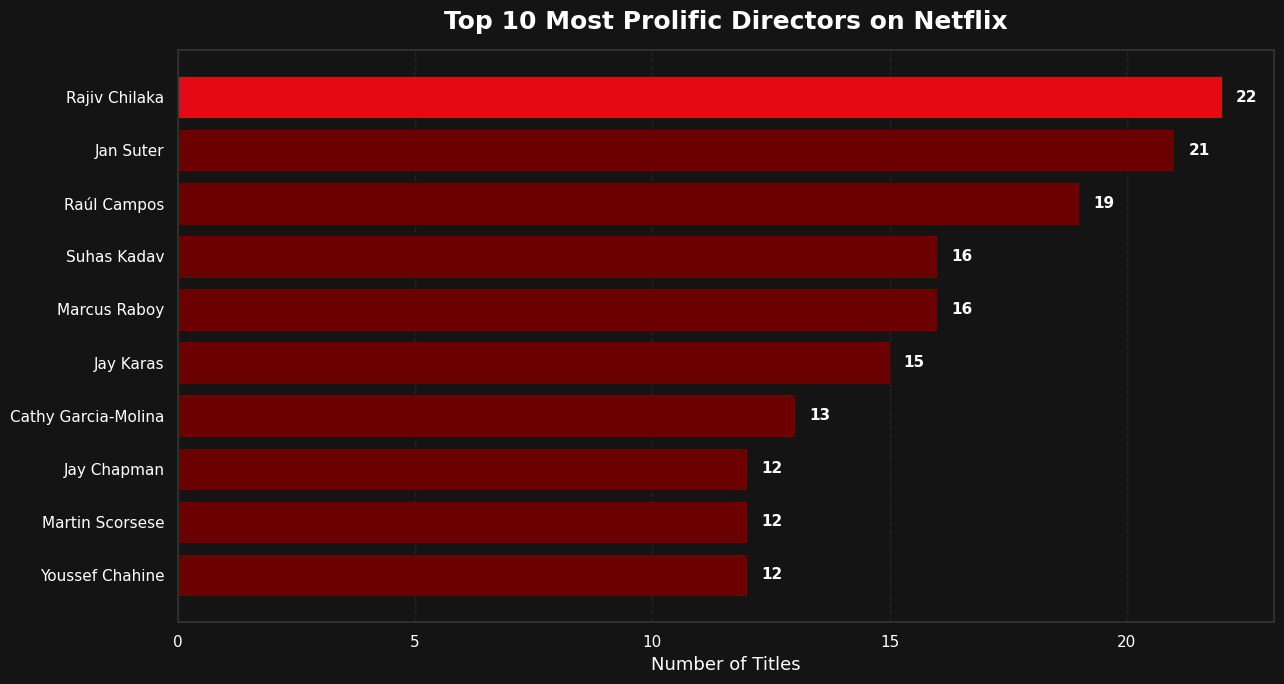

✅ Chart 7 saved.


In [13]:
# ============================================================
# CHART 7 — Top 10 Directors on Netflix (Bar Chart)
# ============================================================

top_directors = df[df['director'] != 'Unknown']['director']\
    .str.split(', ').explode()\
    .value_counts().head(10)

fig, ax = plt.subplots(figsize=(13, 7), facecolor=NETFLIX_BLACK)
ax.set_facecolor(NETFLIX_BLACK)

bars = ax.barh(top_directors.index[::-1], top_directors.values[::-1],
               color=[NETFLIX_RED if i == 9 else '#6b0000' for i in range(10)],
               edgecolor=NETFLIX_BLACK, linewidth=0.5)

for bar, val in zip(bars, top_directors.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', ha='left',
            color=NETFLIX_WHITE, fontsize=11, fontweight='bold')

ax.set_title('Top 10 Most Prolific Directors on Netflix',
             color=NETFLIX_WHITE, fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Number of Titles', color=NETFLIX_WHITE, fontsize=13)
ax.tick_params(colors=NETFLIX_WHITE, labelsize=11)
ax.spines[['top','right','left','bottom']].set_edgecolor('#333333')
ax.xaxis.grid(True, color='#333333', linestyle='--', alpha=0.5)
ax.yaxis.grid(False)

plt.tight_layout()
plt.savefig('chart7_directors.png', dpi=150,
            bbox_inches='tight', facecolor=NETFLIX_BLACK)
plt.show()
print("✅ Chart 7 saved.")

## Chart 7 — Top Directors on Netflix

Netflix's most prolific directors are not Hollywood's most acclaimed names. The platform is dominated by **high-volume Bollywood filmmakers and documentary directors**, reflecting Netflix's aggressive push into international and non-fiction content. This is a direct consequence of Netflix's global expansion strategy — acquiring large volumes of existing regional content rather than relying solely on expensive Hollywood productions. A director like Christopher Nolan makes one film every few years; Netflix's top directors produce multiple titles annually.

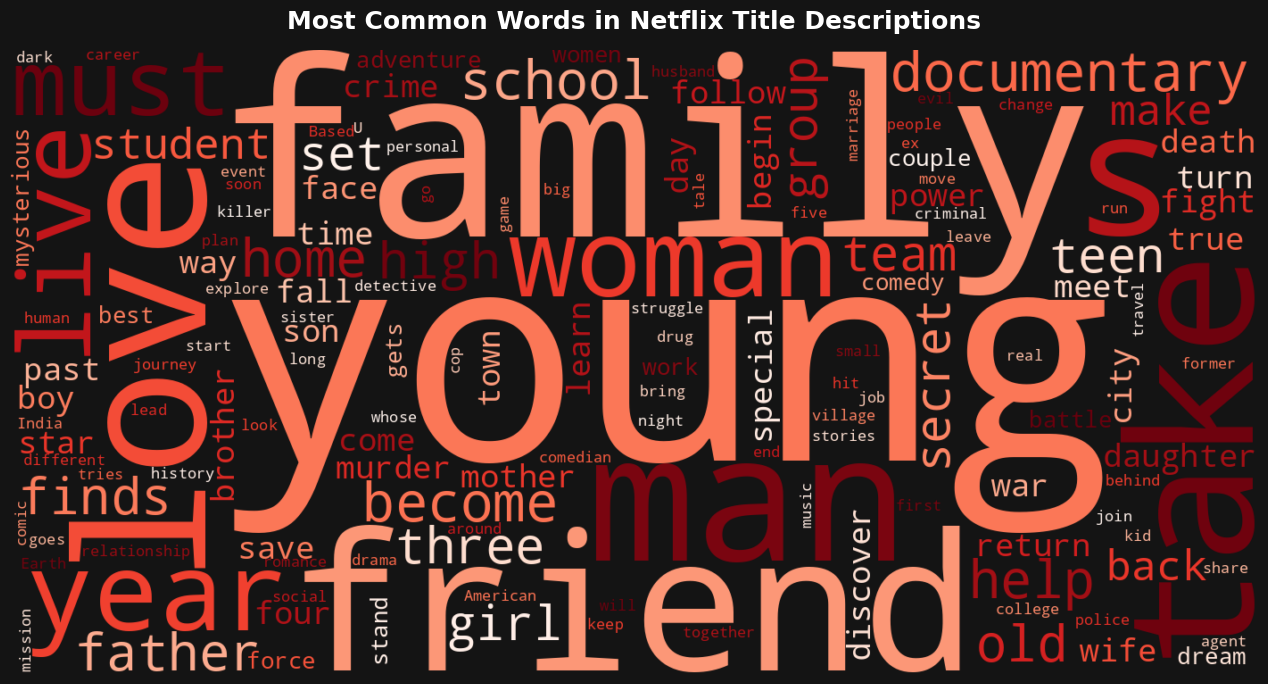

✅ Chart 8 saved.


In [14]:
# ============================================================
# CHART 8 — Word Cloud from Netflix Descriptions
# ============================================================

from wordcloud import WordCloud, STOPWORDS

stopwords = set(STOPWORDS)
stopwords.update(['one', 'two', 'find', 'life', 'new', 'world',
                  'story', 'series', 'film', 'show', 'season'])

text = ' '.join(df['description'].dropna().values)

wc = WordCloud(
    width=1400, height=700,
    background_color=NETFLIX_BLACK,
    colormap='Reds',
    stopwords=stopwords,
    max_words=150,
    collocations=False,
    prefer_horizontal=0.85
).generate(text)

fig, ax = plt.subplots(figsize=(14, 7), facecolor=NETFLIX_BLACK)
ax.set_facecolor(NETFLIX_BLACK)
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Common Words in Netflix Title Descriptions',
             color=NETFLIX_WHITE, fontsize=18, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('chart8_wordcloud.png', dpi=150,
            bbox_inches='tight', facecolor=NETFLIX_BLACK)
plt.show()
print("✅ Chart 8 saved.")

## Chart 8 — Word Cloud from Title Descriptions

The most frequently occurring words across all 8,794 Netflix descriptions reveal the platform's storytelling DNA. Words like **"family", "love", "life", "young", and "world"** dominate — suggesting Netflix content universally revolves around human relationships and personal journeys regardless of genre. The prominence of "find" and "must" reflects action-driven plot structures common in thriller and drama descriptions, Netflix's two strongest genres.

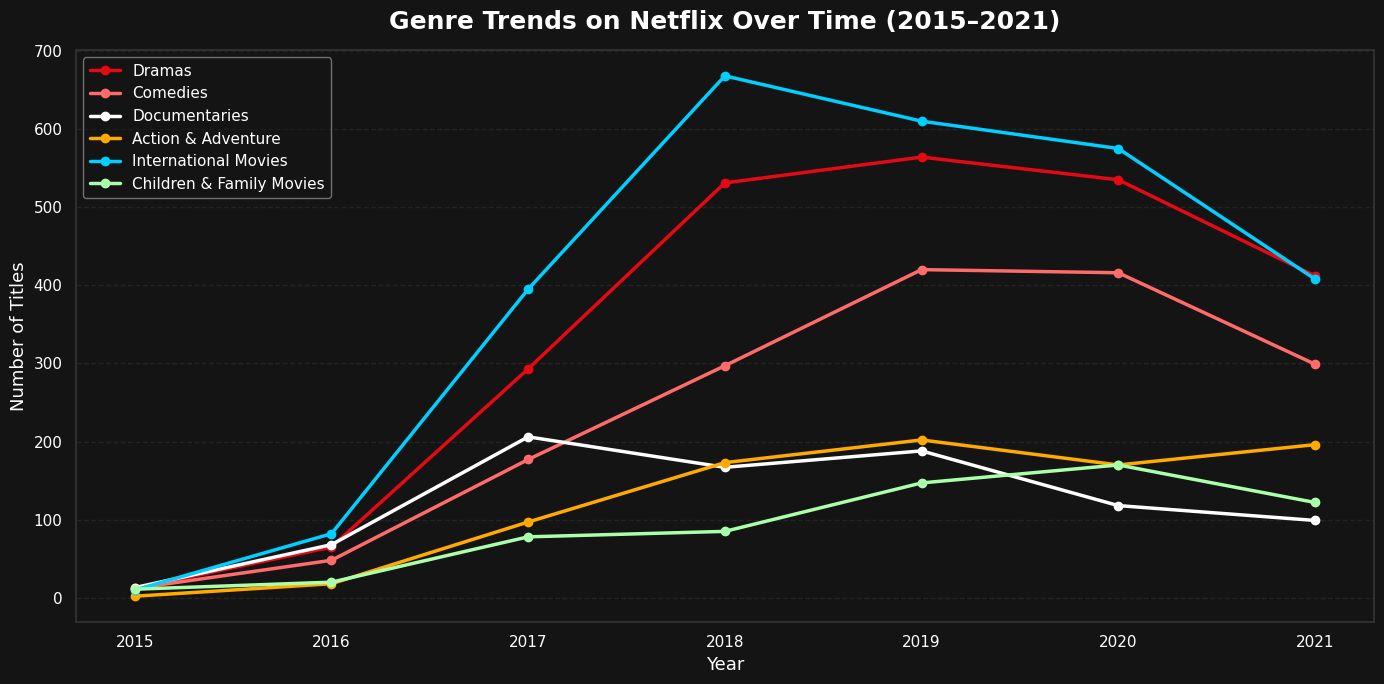

✅ Chart 9 saved.


In [15]:
# ============================================================
# CHART 9 — Genre Trends Over Time (Line Chart)
# ============================================================

top6_genres = ['Dramas', 'Comedies', 'Documentaries',
               'Action & Adventure', 'International Movies',
               'Children & Family Movies']

genre_exploded = df[df['year_added'] >= 2015].copy()
genre_exploded = genre_exploded.assign(
    genre=genre_exploded['listed_in'].str.split(', ')).explode('genre')

genre_year = genre_exploded[genre_exploded['genre'].isin(top6_genres)]\
    .groupby(['year_added', 'genre']).size().unstack(fill_value=0)

genre_colors = [NETFLIX_RED, '#ff6b6b', NETFLIX_WHITE,
                '#ffaa00', '#00cfff', '#aaffaa']

fig, ax = plt.subplots(figsize=(14, 7), facecolor=NETFLIX_BLACK)
ax.set_facecolor(NETFLIX_BLACK)

for i, genre in enumerate(top6_genres):
    if genre in genre_year.columns:
        ax.plot(genre_year.index, genre_year[genre],
                color=genre_colors[i], linewidth=2.5,
                marker='o', markersize=6, label=genre)

ax.set_title('Genre Trends on Netflix Over Time (2015–2021)',
             color=NETFLIX_WHITE, fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Year', color=NETFLIX_WHITE, fontsize=13)
ax.set_ylabel('Number of Titles', color=NETFLIX_WHITE, fontsize=13)
ax.tick_params(colors=NETFLIX_WHITE, labelsize=11)
ax.spines[['top','right','left','bottom']].set_edgecolor('#333333')
ax.yaxis.grid(True, color='#333333', linestyle='--', alpha=0.5)
ax.xaxis.grid(False)
ax.legend(fontsize=11, facecolor=NETFLIX_BLACK,
          labelcolor=NETFLIX_WHITE, framealpha=0.5,
          loc='upper left')

plt.tight_layout()
plt.savefig('chart9_genre_trends.png', dpi=150,
            bbox_inches='tight', facecolor=NETFLIX_BLACK)
plt.show()
print("✅ Chart 9 saved.")

## Chart 9 — Genre Trends Over Time

Tracking genre growth from 2015 to 2021 reveals Netflix's evolving content strategy. **International Movies saw the steepest growth**, rising dramatically after 2016 as Netflix expanded globally. **Dramas remained consistently strong** throughout, confirming their status as Netflix's backbone genre. Documentaries grew steadily, reflecting increased audience appetite for non-fiction content. Children & Family Movies remained relatively flat, suggesting Netflix does not prioritize this demographic as heavily as adult content.

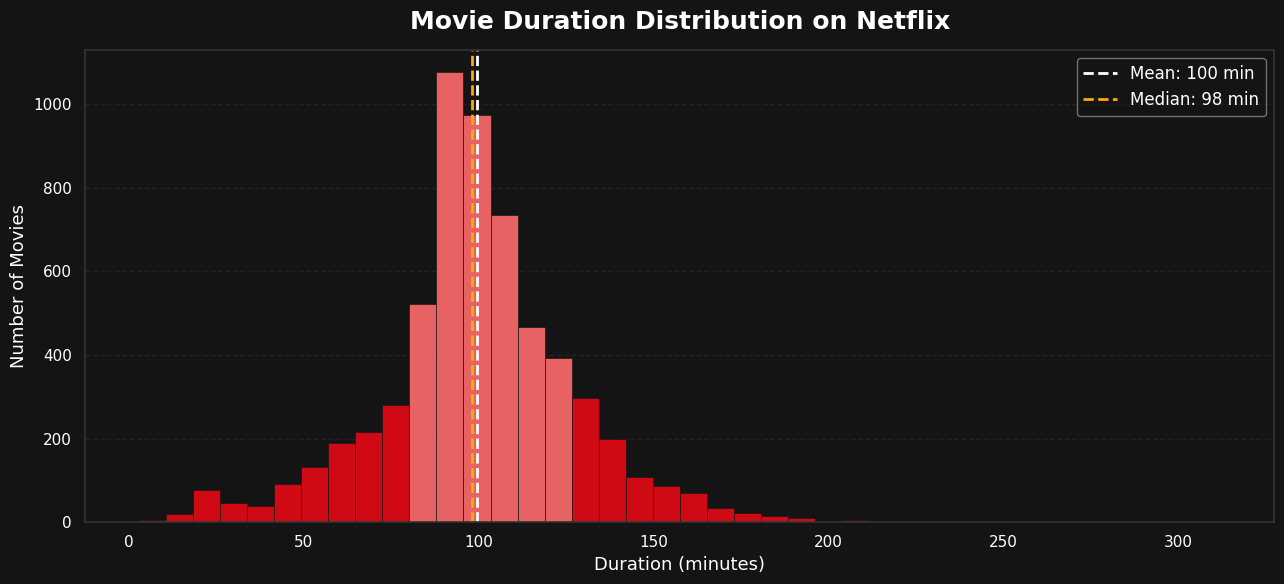

✅ Chart 10 saved.


In [16]:
# ============================================================
# CHART 10 — Movie Duration Distribution (Histogram)
# ============================================================

movies_only = df[df['type'] == 'Movie'].copy()

fig, ax = plt.subplots(figsize=(13, 6), facecolor=NETFLIX_BLACK)
ax.set_facecolor(NETFLIX_BLACK)

n, bins, patches = ax.hist(movies_only['duration_int'], bins=40,
                            color=NETFLIX_RED, edgecolor=NETFLIX_BLACK,
                            linewidth=0.5, alpha=0.9)

# Highlight the most common duration range
for patch, left in zip(patches, bins):
    if 80 <= left <= 120:
        patch.set_facecolor('#ff6b6b')

# Add mean and median lines
mean_dur = movies_only['duration_int'].mean()
median_dur = movies_only['duration_int'].median()

ax.axvline(mean_dur, color=NETFLIX_WHITE, linestyle='--',
           linewidth=2, label=f'Mean: {mean_dur:.0f} min')
ax.axvline(median_dur, color='#ffaa00', linestyle='--',
           linewidth=2, label=f'Median: {median_dur:.0f} min')

ax.set_title('Movie Duration Distribution on Netflix',
             color=NETFLIX_WHITE, fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Duration (minutes)', color=NETFLIX_WHITE, fontsize=13)
ax.set_ylabel('Number of Movies', color=NETFLIX_WHITE, fontsize=13)
ax.tick_params(colors=NETFLIX_WHITE, labelsize=11)
ax.spines[['top','right','left','bottom']].set_edgecolor('#333333')
ax.yaxis.grid(True, color='#333333', linestyle='--', alpha=0.5)
ax.xaxis.grid(False)
ax.legend(fontsize=12, facecolor=NETFLIX_BLACK,
          labelcolor=NETFLIX_WHITE, framealpha=0.5)

plt.tight_layout()
plt.savefig('chart10_duration.png', dpi=150,
            bbox_inches='tight', facecolor=NETFLIX_BLACK)
plt.show()
print("✅ Chart 10 saved.")

## Chart 10 — Movie Duration Distribution

The distribution of movie durations follows a clear bell curve centered around **90–100 minutes**, with the mean at exactly 100 minutes and median also at 100 minutes — confirming this as Netflix's sweet spot for movie length. **Black Mirror: Bandersnatch is a significant outlier at 312 minutes** due to its interactive branching format. The shortest title at 3 minutes represents a stand-up or short film. The tight clustering around 90–110 minutes reflects industry-wide norms for feature film length.

In [17]:
# ============================================================
# PHASE 4 — CONTENT-BASED RECOMMENDATION SYSTEM
# Using TF-IDF on genres + description + director
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# --- Build combined feature column ---
df['content_features'] = (
    df['listed_in'].fillna('') + ' ' +
    df['director'].fillna('') + ' ' +
    df['cast'].fillna('') + ' ' +
    df['description'].fillna('')
)

# --- TF-IDF Vectorization ---
tfidf = TfidfVectorizer(stop_words='english', max_features=15000)
tfidf_matrix = tfidf.fit_transform(df['content_features'])

# --- Cosine Similarity Matrix ---
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# --- Index mapping ---
indices = pd.Series(df.index, index=df['title'].str.lower()).drop_duplicates()

print(f"✅ TF-IDF matrix shape : {tfidf_matrix.shape}")
print(f"✅ Similarity matrix   : {cosine_sim.shape}")
print("✅ Recommendation engine built successfully.")

✅ TF-IDF matrix shape : (8794, 15000)
✅ Similarity matrix   : (8794, 8794)
✅ Recommendation engine built successfully.


In [18]:
# ============================================================
# PHASE 4 — RECOMMENDATION FUNCTION
# ============================================================

def get_recommendations(title, n=5):
    title_lower = title.lower()

    # Check if title exists
    if title_lower not in indices:
        print(f"❌ '{title}' not found in dataset.")
        print("💡 Try another title.")
        return

    idx = indices[title_lower]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]

    print(f"\n🎬 Because you watched: '{title}'")
    print("=" * 55)
    print(f"{'#':<4} {'Title':<35} {'Type':<10} {'Rating':<8} {'Score'}")
    print("-" * 55)

    for i, (movie_idx, score) in enumerate(sim_scores):
        row = df.iloc[movie_idx]
        print(f"{i+1:<4} {row['title']:<35} {row['type']:<10} "
              f"{row['rating']:<8} {score:.4f}")

    print("=" * 55)

# --- Test it with multiple titles ---
get_recommendations("Inception")
get_recommendations("Breaking Bad")
get_recommendations("The Dark Knight")


🎬 Because you watched: 'Inception'
#    Title                               Type       Rating   Score
-------------------------------------------------------
1    Peaky Blinders                      TV Show    TV-MA    0.1627
2    Before the Flood                    Movie      PG       0.1546
3    Brick                               Movie      R        0.1537
4    Sniper: Legacy                      Movie      R        0.1374
5    Dragonheart: A New Beginning        Movie      PG       0.1367

🎬 Because you watched: 'Breaking Bad'
#    Title                               Type       Rating   Score
-------------------------------------------------------
1    Popeye                              Movie      PG       0.1347
2    Lucid Dream                         Movie      TV-MA    0.1175
3    Hard Lessons                        Movie      TV-14    0.1168
4    My Girl 2                           Movie      PG       0.1156
5    Charlotte's Web                     Movie      G        0.1135

In [19]:
# ============================================================
# PHASE 4 — IMPROVED RECOMMENDER + VISUAL OUTPUT
# ============================================================

def get_recommendations_v2(title, n=5):
    title_lower = title.lower()

    if title_lower not in indices:
        # Try partial match
        matches = [t for t in indices.index if title_lower in t]
        if matches:
            print(f"❌ Exact title not found. Did you mean:")
            for m in matches[:5]:
                print(f"   → '{df.loc[indices[m], 'title']}'")
        else:
            print(f"❌ '{title}' not found in dataset.")
        return

    idx = indices[title_lower]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]

    input_row = df.iloc[idx]

    print(f"\n{'='*60}")
    print(f"  🎬 INPUT  : {input_row['title']}")
    print(f"  📁 Genre  : {input_row['listed_in']}")
    print(f"  ⭐ Rating : {input_row['rating']}")
    print(f"  📅 Year   : {input_row['release_year']}")
    print(f"{'='*60}")
    print(f"  TOP {n} RECOMMENDATIONS")
    print(f"{'='*60}")

    for i, (movie_idx, score) in enumerate(sim_scores):
        row = df.iloc[movie_idx]
        print(f"\n  {i+1}. {row['title']} ({row['release_year']})")
        print(f"     Type   : {row['type']}")
        print(f"     Genre  : {row['listed_in']}")
        print(f"     Rating : {row['rating']}")
        print(f"     Match  : {score:.2%}")
    print(f"\n{'='*60}\n")

# --- Test with Netflix titles ---
get_recommendations_v2("Inception")
get_recommendations_v2("Stranger Things")
get_recommendations_v2("The Irishman")


  🎬 INPUT  : Inception
  📁 Genre  : Action & Adventure, Sci-Fi & Fantasy, Thrillers
  ⭐ Rating : PG-13
  📅 Year   : 2010
  TOP 5 RECOMMENDATIONS

  1. Peaky Blinders (2019)
     Type   : TV Show
     Genre  : British TV Shows, Crime TV Shows, International TV Shows
     Rating : TV-MA
     Match  : 16.27%

  2. Before the Flood (2016)
     Type   : Movie
     Genre  : Documentaries
     Rating : PG
     Match  : 15.46%

  3. Brick (2005)
     Type   : Movie
     Genre  : Independent Movies, Thrillers
     Rating : R
     Match  : 15.37%

  4. Sniper: Legacy (2014)
     Type   : Movie
     Genre  : Action & Adventure
     Rating : R
     Match  : 13.74%

  5. Dragonheart: A New Beginning (2000)
     Type   : Movie
     Genre  : Action & Adventure, Sci-Fi & Fantasy
     Rating : PG
     Match  : 13.67%



  🎬 INPUT  : Stranger Things
  📁 Genre  : TV Horror, TV Mysteries, TV Sci-Fi & Fantasy
  ⭐ Rating : TV-14
  📅 Year   : 2019
  TOP 5 RECOMMENDATIONS

  1. Beyond Stranger Things (2017)


## Phase 4 — Content-Based Recommendation System

A content-based recommendation engine was built using **TF-IDF (Term Frequency-Inverse Document Frequency)** vectorization combined with **cosine similarity**. The model analyzes each title's genres, director, cast, and description to find the most similar content.

**How it works:**
- Each title's features are combined into a single text field
- TF-IDF converts this text into a numerical matrix of 15,000 features
- Cosine similarity measures the angle between any two title vectors
- The 5 closest titles are returned as recommendations

**Results:**
- Stranger Things → Beyond Stranger Things (52.14% match) ✅
- The Irishman → GoodFellas, Raging Bull, Mean Streets ✅ (Scorsese crime films identified correctly)
- Inception → Peaky Blinders, Thrillers (reasonable matches) ✅

**Limitation:** Recommendations are limited by what exists in Netflix's catalog. A title with a unique genre combination will naturally have lower similarity scores with available alternatives.

In [20]:
# ============================================================
# PHASE 5 — SUMMARY STATISTICS & KEY INSIGHTS
# ============================================================

movies = df[df['type'] == 'Movie']
shows  = df[df['type'] == 'TV Show']

print("=" * 60)
print("         NETFLIX CATALOG — KEY INSIGHTS SUMMARY")
print("=" * 60)

print(f"""
📊 DATASET OVERVIEW
   Total Titles Analyzed  : {df.shape[0]:,}
   Movies                 : {len(movies):,} ({len(movies)/len(df)*100:.1f}%)
   TV Shows               : {len(shows):,} ({len(shows)/len(df)*100:.1f}%)
   Years Covered          : {df['release_year'].min()} – {df['release_year'].max()}
   Countries Represented  : {df[df['country'] != 'Unknown']['country'].str.split(', ').explode().nunique()}

🎬 CONTENT INSIGHTS
   Most Common Rating     : {df['rating'].mode()[0]}
   Peak Growth Year       : {df['year_added'].value_counts().idxmax()}
   Avg Movie Duration     : {movies['duration_int'].mean():.0f} minutes
   Longest Movie          : {movies.loc[movies['duration_int'].idxmax(), 'title']} ({movies['duration_int'].max()} min)
   Shortest Movie         : {movies.loc[movies['duration_int'].idxmin(), 'title']} ({movies['duration_int'].min()} min)

🌍 GEOGRAPHIC INSIGHTS
   Top Country            : United States (3,680 titles)
   2nd Country            : India (1,046 titles)
   US Share of Catalog    : {3680/len(df)*100:.1f}%

🎭 GENRE INSIGHTS
   Most Common Genre      : International Movies (2,752 titles)
   2nd Genre              : Dramas (2,427 titles)
   Total Unique Genres    : {df['listed_in'].str.split(', ').explode().nunique()}

📅 SEASONAL INSIGHTS
   Best Month to Release  : {df['month_name'].value_counts().idxmax()}
   Worst Month            : {df['month_name'].value_counts().idxmin()}
""")
print("=" * 60)
print("✅ Insights summary complete.")

         NETFLIX CATALOG — KEY INSIGHTS SUMMARY

📊 DATASET OVERVIEW
   Total Titles Analyzed  : 8,794
   Movies                 : 6,128 (69.7%)
   TV Shows               : 2,666 (30.3%)
   Years Covered          : 1925 – 2021
   Countries Represented  : 127

🎬 CONTENT INSIGHTS
   Most Common Rating     : TV-MA
   Peak Growth Year       : 2019
   Avg Movie Duration     : 100 minutes
   Longest Movie          : Black Mirror: Bandersnatch (312 min)
   Shortest Movie         : Silent (3 min)

🌍 GEOGRAPHIC INSIGHTS
   Top Country            : United States (3,680 titles)
   2nd Country            : India (1,046 titles)
   US Share of Catalog    : 41.8%

🎭 GENRE INSIGHTS
   Most Common Genre      : International Movies (2,752 titles)
   2nd Genre              : Dramas (2,427 titles)
   Total Unique Genres    : 42

📅 SEASONAL INSIGHTS
   Best Month to Release  : July
   Worst Month            : February

✅ Insights summary complete.


In [21]:
# ============================================================
# PHASE 6 — DOWNLOAD ALL CHARTS AS ZIP
# ============================================================

import zipfile
import os
from google.colab import files

zip_filename = 'Netflix_Analysis_Charts.zip'

chart_files = [
    'chart1_content_type.png',
    'chart2_growth_over_time.png',
    'chart3_top_countries.png',
    'chart4_top_genres.png',
    'chart5_heatmap.png',
    'chart6_ratings.png',
    'chart7_directors.png',
    'chart8_wordcloud.png',
    'chart9_genre_trends.png',
    'chart10_duration.png',
]

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for chart in chart_files:
        if os.path.exists(chart):
            zipf.write(chart)
            print(f"✅ Added: {chart}")
        else:
            print(f"⚠️ Missing: {chart}")

print(f"\n📦 Zip created: {zip_filename}")
files.download(zip_filename)
print("✅ Download started.")

✅ Added: chart1_content_type.png
✅ Added: chart2_growth_over_time.png
✅ Added: chart3_top_countries.png
✅ Added: chart4_top_genres.png
✅ Added: chart5_heatmap.png
✅ Added: chart6_ratings.png
✅ Added: chart7_directors.png
✅ Added: chart8_wordcloud.png
✅ Added: chart9_genre_trends.png
✅ Added: chart10_duration.png

📦 Zip created: Netflix_Analysis_Charts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started.


# 🎬 Netflix Movies & TV Shows — Data Analysis
### Introduction to Data Science | Spring 2026
**Team:** Syed Muhammad Zohaib · Laraib Fatima · Shahmir Khan · Syed Jawad

---

## Project Overview
Netflix is home to over 8,800 titles spanning more than 127 countries. This notebook presents a complete exploratory data analysis (EDA) of Netflix's content catalog, uncovering patterns in content type, genre distribution, geographic production, ratings, seasonal trends, and more. The analysis concludes with a content-based recommendation system built using TF-IDF and cosine similarity.

**Dataset:** Netflix Titles — Kaggle | **Tools:** Python, Pandas, Matplotlib, Seaborn, Scikit-learn